In [1]:
import scanpy as sc
import pandas as pd

# 读取 h5ad 文件
file_path = "/cluster3/labData/jiamao/MouseBrain/h5ad/T300_T309_SCT_merge_bayes_anno.h5ad"
adata = sc.read_h5ad(file_path)

# 查看元数据
adata.obs.head()

,orig.ident,nCount_Spatial,nFeature_Spatial,sampleid,percent.mito,coor_x,coor_y,coor_x_ad2,coor_y_ad2,scc.annoL1,nCount_RNA,nFeature_RNA
T300-ACGCACTAGAGCAAGGCCGT,ACGCACTAGAGCAAGGCCGT-T300,5139.0,1802,T300,0.024295,84.0,39.0,83.247018,161.495085,HY-LHAv,5139.0,1802
T300-CATGGTCGAGGAGTCCGGGG,CATGGTCGAGGAGTCCGGGG-T300,3657.0,1337,T300,0.023497,76.0,53.0,83.737997,177.612124,HY-LHAv,3657.0,1337
T300-ATTACATACGACGATACGCG,ATTACATACGACGATACGCG-T300,3298.0,1286,T300,0.030312,106.0,64.0,52.085382,173.240401,STR-CPm,3298.0,1286
T300-TTGCCCCTCGGGGGGGTAGG,TTGCCCCTCGGGGGGGTAGG-T300,4301.0,1518,T300,0.038810,105.0,95.0,38.414711,201.081248,STR-CPl,4301.0,1518
T300-TGATCCGCCCCTCATCCAGT,TGATCCGCCCCTCATCCAGT-T300,4259.0,1537,T300,0.031925,96.0,98.0,44.952824,207.955335,STR-CPm,4259.0,1537


In [2]:
adata

AnnData object with n_obs × n_vars = 98757 × 21806
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'sampleid', 'percent.mito', 'coor_x', 'coor_y', 'coor_x_ad2', 'coor_y_ad2', 'scc.annoL1', 'nCount_RNA', 'nFeature_RNA'
    var: 'name'

In [3]:
adata.X

<98757x21806 sparse matrix of type '<class 'numpy.float32'>'
	with 325305242 stored elements in Compressed Sparse Column format>

In [5]:
import numpy as np

# 取出前 100 个非零值
data_sample = adata.X.data[:100]

# 检查是否全是整数
is_integer = np.all(np.equal(np.mod(data_sample, 1), 0))
print(f"是否为整数: {is_integer}")

是否为整数: True


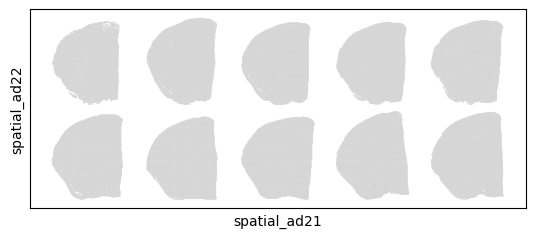

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

# 确保坐标已存入 obsm
adata.obsm['spatial'] = adata.obs[['coor_x_ad2', 'coor_y_ad2']].values.astype(float)

# 绘图
ax = sc.pl.embedding(adata, basis="spatial", show=False, size=2)

# 强制修正比例
ax.set_aspect('equal')
plt.show()